# CNN (Convolutional Neural Network) 실습

**학습 목표**
- MLP의 한계를 이해하고 CNN이 등장한 배경 파악
- CNN의 핵심 구성요소(합성곱, 풀링, 완전연결층) 이해
- PyTorch로 CIFAR-10 데이터를 분류하는 CNN 모델 구현
- 계층적 특징 추출의 원리 체감

---

## 0. 라이브러리 import 및 환경 설정

In [10]:
# 공통 실습 환경 설치 (최초 1회 실행)
# 필요한 라이브러리 설치 (Colab이나 새 환경에서)
# 로컬 환경에서는 이미 설치되어 있다면 주석처리
!pip install -q \
    "torch>=2.1.0" \
    "torchvision>=0.16.0" \
    "matplotlib>=3.8.0" \
    "numpy>=1.24.0,<2.0.0" \
    "transformers==4.57.1"

# 설치 확인
import torch                     # PyTorch 핵심 라이브러리 (텐서 연산, 자동 미분 등)
import torch.nn as nn            # 신경망 모듈 (레이어, 손실 함수 등을 정의)
import torch.optim as optim      # 최적화 알고리즘 모듈 (SGD, Adam 등)
import torchvision               # 컴퓨터 비전 유틸리티 (데이터셋, 모델, 변환)
import matplotlib.pyplot as plt
import numpy as np               # 수치 연산 라이브러리 (배열 연산, 통계 등)
import torchvision.transforms as transforms  # 이미지 전처리/변환 함수 모음

You should consider upgrading via the '/Users/isaac/SSAFY/AI/15기_수업/.venv/bin/python3 -m pip install --upgrade pip' command.


In [11]:
# 재현성을 위한 시드 고정
torch.manual_seed(42)

# GPU 사용 가능 여부 확인
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"사용 중인 디바이스: {device}")

사용 중인 디바이스: cpu


---

## 1. MLP의 한계 복습

### 왜 CNN이 필요한가?

지난 시간에 배운 **MLP(Multi-Layer Perceptron)**는 이미지를 처리할 때 치명적인 한계가 있습니다.

#### MLP가 이미지를 처리하는 방식

1. **2차원 이미지를 1차원으로 평탄화(Flatten)**
   - 28×28 이미지 → 784개의 일렬 벡터
   - 32×32×3 컬러 이미지 → 3,072개의 일렬 벡터

2. **공간적 정보 손실**
   - 픽셀 간의 상하좌우 이웃 관계가 완전히 사라짐
   - 지역적 패턴(선, 모서리, 질감)을 감지할 수 없음
   - 같은 물체가 다른 위치에 있으면 완전히 다른 입력으로 인식


### MLP 모델 정의 (복습)

In [14]:
# 지난 시간에 배운 MLP 구조
mlp_model = nn.Sequential(
    nn.Flatten(),            # [B, 1, 28, 28] → [B, 784]
    nn.Linear(784, 256),     # 입력: 784개 픽셀 → 은닉층: 256개 뉴런
    nn.ReLU(),
    nn.Linear(256, 128),     # 은닉층1: 256 → 은닉층2: 128
    nn.ReLU(),
    nn.Linear(128, 10)       # 은닉층2: 128 → 출력: 10개 클래스
)

print(mlp_model)
print(f"\n총 파라미터 수: {sum(p.numel() for p in mlp_model.parameters()):,}")

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): ReLU()
  (3): Linear(in_features=256, out_features=128, bias=True)
  (4): ReLU()
  (5): Linear(in_features=128, out_features=10, bias=True)
)

총 파라미터 수: 235,146


**핵심 문제점:**
- 첫 번째 Linear 층이 784개 입력을 받음 → 이미지가 1차원으로 펼쳐진 상태
- 픽셀1과 픽셀2가 '옆에 붙어있었다'는 정보를 알 수 없음
- 픽셀1과 픽셀29가 '위아래였다'는 정보를 알 수 없음
- 지역적 패턴(소매, 버튼, 질감)을 효과적으로 학습할 수 없음

---

## 2. CIFAR-10 데이터셋 준비

### CIFAR-10이란?

- **10개 클래스**: 비행기(airplane), 자동차(automobile), 새(bird), 고양이(cat), 사슴(deer), 개(dog), 개구리(frog), 말(horse), 배(ship), 트럭(truck)
- **이미지 크기**: 32×32 픽셀
- **채널**: RGB 컬러 이미지 (3채널)
- **데이터 규모**: 학습용 50,000장, 테스트용 10,000장

### 데이터 전처리 (Transform)

딥러닝 모델이 이미지를 잘 학습하려면 **정규화(Normalization)**가 필수입니다.

1. **ToTensor()**: 이미지를 텐서로 변환하고 픽셀 값을 [0, 255] → [0.0, 1.0] 범위로 스케일링
2. **Normalize()**: 평균을 0, 표준편차를 1에 가깝게 조정 → 학습 안정화 및 성능 향상

In [15]:
# CIFAR-10 데이터 전처리 정의
transform = transforms.Compose([
    transforms.ToTensor(),                                      # PIL Image → Tensor, [0, 255] → [0.0, 1.0]
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))     # 평균 0.5, 표준편차 0.5로 정규화 → [-1.0, 1.0]
])

# 학습 데이터셋
trainset = torchvision.datasets.CIFAR10(
    root='./data',           # 데이터 저장 경로
    train=True,              # 학습용 데이터
    download=True,           # 없으면 자동 다운로드
    transform=transform      # 전처리 적용
)

# 테스트 데이터셋
testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,             # 테스트용 데이터
    download=True,
    transform=transform
)

print(f"학습 데이터 수: {len(trainset):,}장")
print(f"테스트 데이터 수: {len(testset):,}장")
print(f"\n클래스 목록: {trainset.classes}")

학습 데이터 수: 50,000장
테스트 데이터 수: 10,000장

클래스 목록: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


### DataLoader 생성

**DataLoader의 역할:**
- 전체 데이터를 **미니배치(mini-batch)** 단위로 묶어서 제공
- 데이터 순서를 **무작위로 섞기(shuffle)** → 모델이 데이터 순서에 편향되지 않음
- 효율적인 메모리 사용 및 병렬 처리

In [16]:
batch_size = 128

trainloader = torch.utils.data.DataLoader(
    trainset, 
    batch_size=batch_size,  # 한 번에 128개씩 처리
    shuffle=True,           # 매 epoch마다 데이터 순서 섞기
    num_workers=2           # 데이터 로딩 병렬 처리 (CPU 코어 활용)
)

testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=batch_size,
    shuffle=False,          # 테스트는 순서 유지
    num_workers=2
)

print(f"배치 크기: {batch_size}")
print(f"학습 배치 수: {len(trainloader)}")
print(f"테스트 배치 수: {len(testloader)}")

배치 크기: 128
학습 배치 수: 391
테스트 배치 수: 79


### 샘플 이미지 확인

배치 이미지 shape: torch.Size([128, 3, 32, 32])
배치 레이블 shape: torch.Size([128])


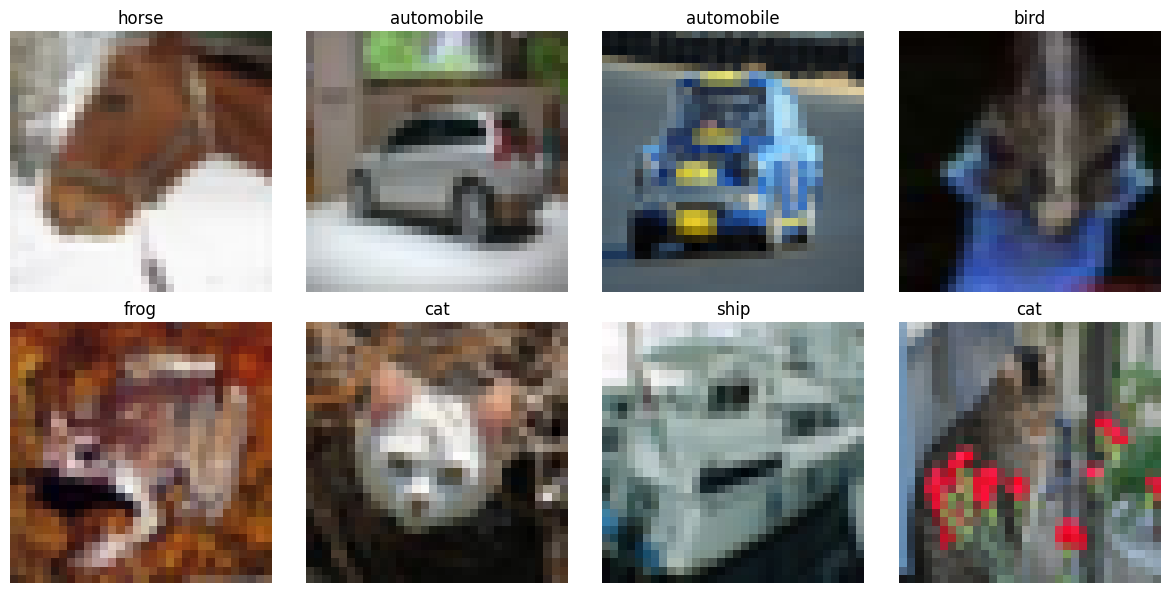

In [17]:
# 샘플 배치 가져오기
dataiter = iter(trainloader)
images, labels = next(dataiter)

print(f"배치 이미지 shape: {images.shape}")  # [128, 3, 32, 32]
print(f"배치 레이블 shape: {labels.shape}")  # [128]

# 정규화 해제 함수 (시각화를 위해)
def denormalize(img):
    img = img * 0.5 + 0.5  # [-1, 1] → [0, 1]
    return img

# 8개 샘플 시각화
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    img = denormalize(images[i])
    img = img.numpy().transpose(1, 2, 0)  # [C, H, W] → [H, W, C]
    ax.imshow(img)
    ax.set_title(f"{trainset.classes[labels[i]]}", fontsize=12)
    ax.axis('off')
    
plt.tight_layout()
plt.show()

---

## 3. CNN 모델 설계

### CNN의 구조

CNN은 크게 두 부분으로 구성됩니다:

**Part 1: 특징 추출기 (Feature Extractor)**
- 합성곱 층(Convolution Layer): 이미지에서 패턴 추출
- 활성화 함수(ReLU): 비선형성 추가
- 풀링 층(Pooling Layer): 특징 맵 크기 축소, 과적합 방지

**Part 2: 분류기 (Classifier)**
- 평탄화(Flatten): 3D 특징 맵 → 1D 벡터
- 완전 연결 층(Fully Connected Layer): 최종 분류

---

### 핵심 개념 1: 합성곱(Convolution)

**역할**: 이미지에서 특징(선, 모서리, 질감 등)을 추출

**동작 원리**:
- **필터(커널)**가 이미지 위를 슬라이딩하며 이동
- 각 위치에서 필터와 이미지의 겹치는 부분을 원소별로 곱한 후 합산
- 이 과정을 통해 **특징 맵(Feature Map)** 생성

**PyTorch 구현**:
```python
nn.Conv2d(in_channels, out_channels, kernel_size)
```
- `in_channels`: 입력 채널 수 (RGB는 3)
- `out_channels`: 필터 개수 (생성될 특징 맵 수)
- `kernel_size`: 필터 크기 (예: 5×5)

---

### 핵심 개념 2: 풀링(Pooling)

**역할**: 특징 맵의 크기를 줄여 연산 효율성 향상 및 과적합 방지

**Max Pooling**:
- 특징 맵을 작은 구역(예: 2×2)으로 나눔
- 각 구역에서 **가장 큰 값**만 남기고 나머지 제거
- 결과적으로 특징 맵의 가로/세로 크기가 절반으로 축소

**PyTorch 구현**:
```python
nn.MaxPool2d(kernel_size, stride)
```

---

### 핵심 개념 3: 계층적 특징 추출

CNN은 여러 합성곱 층을 쌓아올려 **단순한 패턴 → 복잡한 패턴**을 학습합니다.

- **낮은 계층**: 선, 모서리, 색상 같은 기초 특징
- **중간 계층**: 눈, 코, 바퀴 같은 구성 요소
- **높은 계층**: 얼굴, 자동차 같은 전체 물체

In [22]:
import torch.nn.functional as F

# CNN 모델 정의
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        
        # Part 1: 특징 추출기
        # 첫 번째 합성곱 블록
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5)
        # 입력: [B, 3, 32, 32] → 출력: [B, 6, 28, 28]
        # (32 - 5 + 1 = 28, padding 없이 크기가 줄어듦)
        
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        # 입력: [B, 6, 28, 28] → 출력: [B, 6, 14, 14]
        # (28 / 2 = 14, 크기가 절반으로)
        
        # 두 번째 합성곱 블록
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5)
        # 입력: [B, 6, 14, 14] → 출력: [B, 16, 10, 10]
        # (14 - 5 + 1 = 10)
        # 풀링 후: [B, 16, 5, 5]
        
        # Part 2: 분류기 (완전 연결 층)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        # 입력: 16×5×5 = 400개 뉴런
        
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)
        # 최종 출력: 10개 클래스
        
    def forward(self, x):
        # 입력 x: [B, 3, 32, 32]
        
        # 첫 번째 합성곱 블록
        x = self.conv1(x)           # → [B, 6, 28, 28]
        x = F.relu(x)               # ReLU 활성화
        x = self.pool(x)            # → [B, 6, 14, 14]
        
        # 두 번째 합성곱 블록
        x = self.conv2(x)           # → [B, 16, 10, 10]
        x = F.relu(x)
        x = self.pool(x)            # → [B, 16, 5, 5]
        
        # 평탄화: 3D → 1D
        x = x.view(-1, 16 * 5 * 5)  # → [B, 400]
        
        # 완전 연결 층
        x = F.relu(self.fc1(x))     # → [B, 120]
        x = F.relu(self.fc2(x))     # → [B, 84]
        x = self.fc3(x)             # → [B, 10] (최종 출력, 활성화 없음)
        
        return x

# 모델 생성 및 디바이스로 이동
net = Net().to(device)
print(net)
print(f"\n총 파라미터 수: {sum(p.numel() for p in net.parameters()):,}")

Net(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

총 파라미터 수: 62,006


### 모델 구조 요약

```
입력 [3, 32, 32]
    ↓
Conv2d(3→6, 5×5) → [6, 28, 28]
    ↓
ReLU + MaxPool(2×2) → [6, 14, 14]
    ↓
Conv2d(6→16, 5×5) → [16, 10, 10]
    ↓
ReLU + MaxPool(2×2) → [16, 5, 5]
    ↓
Flatten → [400]
    ↓
FC(400→120) → ReLU
    ↓
FC(120→84) → ReLU
    ↓
FC(84→10) → 출력 [10]
```

---

## 4. 손실 함수 및 옵티마이저 정의

### 손실 함수(Loss Function)

**CrossEntropyLoss**: 다중 클래스 분류 문제에서 가장 많이 사용
- 모델의 예측과 실제 정답 사이의 차이를 측정
- 내부적으로 Softmax + NLL Loss를 결합

### 옵티마이저(Optimizer)

**SGD (Stochastic Gradient Descent)**
- 가장 기본적인 경사하강법
- `momentum`: 이전 업데이트 방향을 일부 유지하여 학습 안정화
- `lr` (learning rate): 학습률, 가중치 업데이트 크기 결정

In [23]:
# 손실 함수 정의
criterion = nn.CrossEntropyLoss()

# 옵티마이저 정의
optimizer = optim.SGD(
    net.parameters(),    # 업데이트할 파라미터
    lr=0.001,            # 학습률
    momentum=0.9         # 모멘텀
)

print(f"손실 함수: {criterion}")
print(f"옵티마이저: {optimizer}")

손실 함수: CrossEntropyLoss()
옵티마이저: SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    momentum: 0.9
    nesterov: False
    weight_decay: 0
)


---

## 5. 모델 학습

### 학습 과정

1. **Forward Pass**: 입력 데이터를 모델에 통과시켜 예측 생성
2. **Loss 계산**: 예측과 정답 사이의 오차 측정
3. **Backward Pass**: 오차를 역전파하여 그레이디언트 계산
4. **Parameter Update**: 옵티마이저로 가중치 업데이트

이 과정을 여러 **에포크(epoch)** 동안 반복합니다.

In [24]:
num_epochs = 10  # 전체 데이터를 10번 반복 학습

print("학습 시작...\n")

for epoch in range(num_epochs):
    running_loss = 0.0
    
    for i, (inputs, labels) in enumerate(trainloader):
        # 데이터를 디바이스로 이동
        inputs, labels = inputs.to(device), labels.to(device)
        
        # 1. 이전 그레이디언트 초기화
        optimizer.zero_grad()
        
        # 2. Forward Pass: 예측 생성
        outputs = net(inputs)
        
        # 3. Loss 계산
        loss = criterion(outputs, labels)
        
        # 4. Backward Pass: 그레이디언트 계산
        loss.backward()
        
        # 5. 파라미터 업데이트
        optimizer.step()
        
        # 통계 수집
        running_loss += loss.item()
        
        # 100 배치마다 중간 결과 출력
        if i % 100 == 99:
            print(f"[Epoch {epoch + 1}, Batch {i + 1:5d}] loss: {running_loss / 100:.3f}")
            running_loss = 0.0

print("\n학습 완료!")

학습 시작...

[Epoch 1, Batch   100] loss: 2.304
[Epoch 1, Batch   200] loss: 2.303
[Epoch 1, Batch   300] loss: 2.303
[Epoch 2, Batch   100] loss: 2.300
[Epoch 2, Batch   200] loss: 2.298
[Epoch 2, Batch   300] loss: 2.296
[Epoch 3, Batch   100] loss: 2.287
[Epoch 3, Batch   200] loss: 2.278
[Epoch 3, Batch   300] loss: 2.260
[Epoch 4, Batch   100] loss: 2.170
[Epoch 4, Batch   200] loss: 2.089
[Epoch 4, Batch   300] loss: 2.034
[Epoch 5, Batch   100] loss: 1.968
[Epoch 5, Batch   200] loss: 1.935
[Epoch 5, Batch   300] loss: 1.916
[Epoch 6, Batch   100] loss: 1.867
[Epoch 6, Batch   200] loss: 1.852
[Epoch 6, Batch   300] loss: 1.823
[Epoch 7, Batch   100] loss: 1.768
[Epoch 7, Batch   200] loss: 1.766
[Epoch 7, Batch   300] loss: 1.750
[Epoch 8, Batch   100] loss: 1.707
[Epoch 8, Batch   200] loss: 1.684
[Epoch 8, Batch   300] loss: 1.684
[Epoch 9, Batch   100] loss: 1.639
[Epoch 9, Batch   200] loss: 1.635
[Epoch 9, Batch   300] loss: 1.620
[Epoch 10, Batch   100] loss: 1.603
[Epoch 10

---

## 6. 모델 평가

### 테스트 데이터로 성능 측정

학습이 끝난 모델을 **처음 보는 테스트 데이터**로 평가합니다.
- 학습 데이터에서만 잘하는 건 '암기'
- 테스트 데이터에서 잘해야 진짜 '이해'

In [25]:
# 평가 모드로 전환 (Dropout, BatchNorm 등 비활성화)
net.eval()

correct = 0
total = 0

# 그레이디언트 계산 비활성화 (메모리 절약)
with torch.no_grad():
    for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        # 예측
        outputs = net(inputs)
        
        # 가장 높은 점수를 받은 클래스 선택
        _, predicted = torch.max(outputs, 1)
        
        # 정확도 계산
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"\n전체 테스트 데이터 10,000장에 대한 정확도: {accuracy:.2f}%")
print(f"맞춘 개수: {correct:,} / {total:,}")


전체 테스트 데이터 10,000장에 대한 정확도: 42.59%
맞춘 개수: 4,259 / 10,000


### 클래스별 정확도 확인

In [26]:
# 클래스별 정확도 계산
class_correct = [0] * 10
class_total = [0] * 10

with torch.no_grad():
    for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = net(inputs)
        _, predicted = torch.max(outputs, 1)
        
        # 클래스별로 통계 수집
        for label, prediction in zip(labels, predicted):
            if label == prediction:
                class_correct[label] += 1
            class_total[label] += 1

# 결과 출력
print("\n클래스별 정확도:")
print("-" * 50)
for i in range(10):
    class_name = trainset.classes[i]
    accuracy = 100 * class_correct[i] / class_total[i]
    print(f"{class_name:12s}: {accuracy:5.2f}% ({class_correct[i]:4d} / {class_total[i]:4d})")


클래스별 정확도:
--------------------------------------------------
airplane    : 45.80% ( 458 / 1000)
automobile  : 51.10% ( 511 / 1000)
bird        : 17.70% ( 177 / 1000)
cat         : 20.20% ( 202 / 1000)
deer        : 25.80% ( 258 / 1000)
dog         : 33.20% ( 332 / 1000)
frog        : 65.70% ( 657 / 1000)
horse       : 55.20% ( 552 / 1000)
ship        : 48.80% ( 488 / 1000)
truck       : 62.40% ( 624 / 1000)


---

## 7. 예측 결과 시각화

실제로 모델이 어떻게 예측하는지 샘플 이미지로 확인해봅시다.

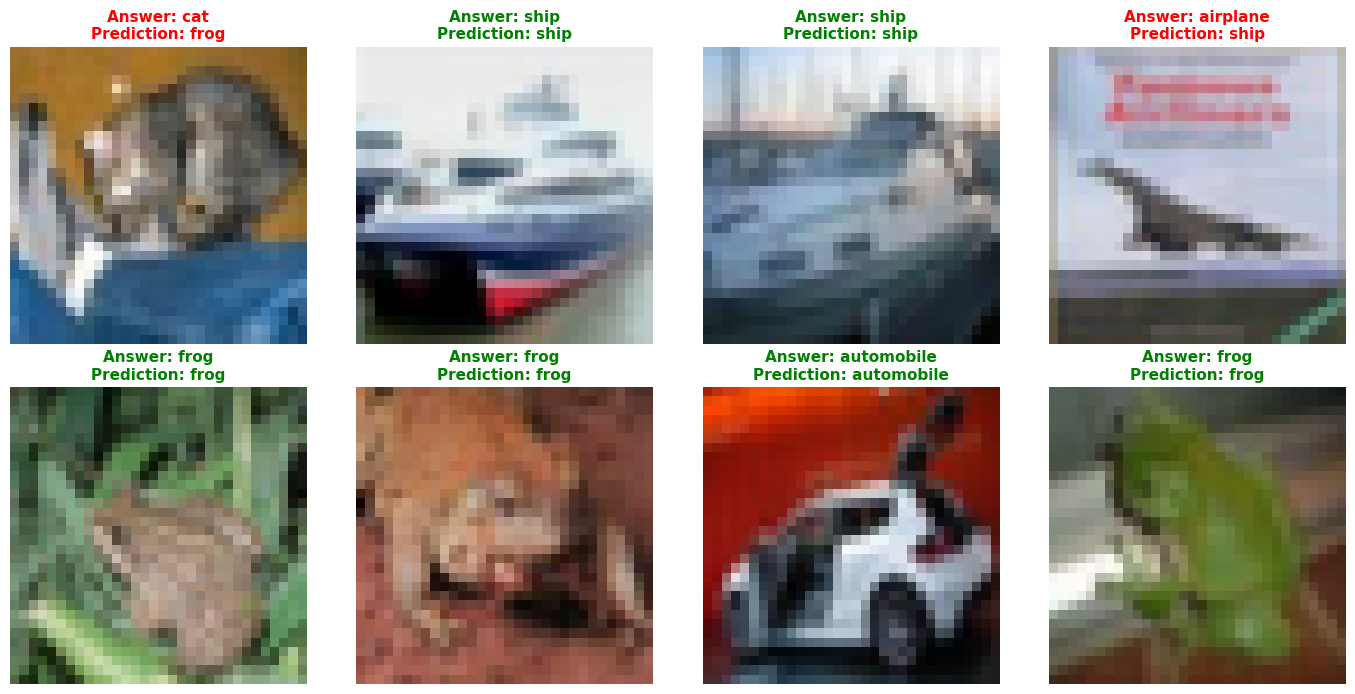

✅ 초록색: 정답 / ❌ 빨간색: 오답


In [28]:
# 테스트 데이터에서 샘플 배치 가져오기
dataiter = iter(testloader)
images, labels = next(dataiter)

# GPU로 이동
images = images.to(device)

# 예측
net.eval()
with torch.no_grad():
    outputs = net(images)
    _, predicted = torch.max(outputs, 1)

# CPU로 이동 (시각화를 위해)
images = images.cpu()
predicted = predicted.cpu()

# 8개 샘플 시각화
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    img = denormalize(images[i])
    img = img.numpy().transpose(1, 2, 0)
    ax.imshow(img)
    
    # 정답과 예측 표시
    true_label = trainset.classes[labels[i]]
    pred_label = trainset.classes[predicted[i]]
    
    color = 'green' if labels[i] == predicted[i] else 'red'
    ax.set_title(f"Answer: {true_label}\nPrediction: {pred_label}", 
                 fontsize=11, color=color, fontweight='bold')
    ax.axis('off')
    
plt.tight_layout()
plt.show()

print("✅ 초록색: 정답 / ❌ 빨간색: 오답")

---

## 8. CNN vs MLP 비교

### 파라미터 수 비교

In [29]:
# CIFAR-10용 MLP 모델 (비교용)
mlp_cifar = nn.Sequential(
    nn.Flatten(),                # [B, 3, 32, 32] → [B, 3072]
    nn.Linear(3072, 512),
    nn.ReLU(),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Linear(256, 10)
)

mlp_params = sum(p.numel() for p in mlp_cifar.parameters())
cnn_params = sum(p.numel() for p in net.parameters())

print("=" * 50)
print("모델 비교")
print("=" * 50)
print(f"MLP 파라미터 수: {mlp_params:,}")
print(f"CNN 파라미터 수: {cnn_params:,}")
print(f"차이: {mlp_params - cnn_params:,} (MLP가 {mlp_params / cnn_params:.1f}배 많음)")
print("\n💡 CNN은 더 적은 파라미터로도 공간적 정보를 효과적으로 학습!")

모델 비교
MLP 파라미터 수: 1,707,274
CNN 파라미터 수: 62,006
차이: 1,645,268 (MLP가 27.5배 많음)

💡 CNN은 더 적은 파라미터로도 공간적 정보를 효과적으로 학습!


### 핵심 차이점 정리

| 구분 | MLP | CNN |
|------|-----|-----|
| **입력 형태** | 1D 벡터 (평탄화 필요) | 2D/3D 유지 |
| **공간 정보** | 손실됨 | 유지됨 |
| **지역적 패턴** | 감지 어려움 | 효과적으로 감지 |
| **파라미터 수** | 많음 (완전 연결) | 적음 (가중치 공유) |
| **위치 불변성** | 없음 | 있음 (필터가 이동) |
| **계층적 학습** | 어려움 | 자연스러움 |

---

---

## 10. 추가 실험 아이디어

시간이 남으면 아래 실험들을 시도해보세요:

### 1. 에포크 수 늘리기
```python
num_epochs = 20  # 더 오래 학습하면 성능 향상?
```

### 2. 배치 크기 변경
```python
batch_size = 64   # 작게 → 학습 느리지만 정확
batch_size = 256  # 크게 → 학습 빠르지만 불안정?
```

### 3. 학습률 조정
```python
optimizer = optim.SGD(net.parameters(), lr=0.01)   # 더 크게
optimizer = optim.SGD(net.parameters(), lr=0.0001) # 더 작게
```

### 4. 다른 옵티마이저 사용
```python
optimizer = optim.Adam(net.parameters(), lr=0.001)  # Adam 사용
```

### 5. 모델 구조 변경
- 필터 개수 늘리기: `nn.Conv2d(3, 12, 5)` (6 → 12)
- 합성곱 층 추가하기: conv3, conv4 추가
- 완전 연결 층 크기 조정

---

## 정리 및 요약

### 오늘 배운 내용

1. **MLP의 한계**
   - 2D 이미지를 1D로 평탄화 → 공간 정보 손실
   - 지역적 패턴 감지 불가
   - 파라미터 수가 많고 비효율적

2. **CNN의 등장 배경**
   - 2D 구조 유지하며 이미지 처리
   - 필터(커널)로 지역적 패턴 추출
   - 계층적으로 단순 → 복잡한 특징 학습

3. **CNN의 핵심 구성요소**
   - **합성곱 층**: 특징 추출 (`nn.Conv2d`)
   - **풀링 층**: 크기 축소 (`nn.MaxPool2d`)
   - **완전 연결 층**: 최종 분류 (`nn.Linear`)

4. **실습 파이프라인**
   - 데이터 준비 → 모델 설계 → 손실/옵티마이저 정의 → 학습 → 평가

### CNN의 장점

-  공간적 정보 보존
-  가중치 공유로 파라미터 효율성
-  위치 불변성 (Translation Invariance)
-  계층적 특징 학습

### 다음 단계

- **더 깊은 CNN**: VGG, ResNet 같은 최신 아키텍처
- **전이 학습**: 사전 학습된 모델 활용
- **데이터 증강**: 회전, 반전 등으로 데이터 다양화
- **정규화 기법**: Dropout, Batch Normalization

